# 보건의료 데이터분석 심화 — 5주차 실습
## 가중 기술통계와 Table 1

---

**실습 자료** — 4주차와 같은 자료를 씁니다.
`knhanes_like_week4.csv` (n = 5,367 · 263개 조사구 · 18개 층) · `codebook_week4.csv`

| 파트 | 내용 |
|---|---|
| **실습 ①** | 분포 진단 → 정규성 검정의 한계 → 가중 분위수 → 요약통계 결정 |
| **실습 ②** | 설계 기반 집단 비교 → SMD → Table 1 완성 → 각주 |

> 4주차에 만든 `svymean`, `svymean_domain` 함수를 그대로 재사용합니다.
> 노트북 앞부분(0-2)에 모아 두었으니 실행하고 시작하십시오.
> **매번 새로 짜지 않는 것도 재현가능한 분석의 일부입니다.**

---

### 이 노트북 사용법

- `# TODO` 가 붙은 셀이 여러분이 채울 곳입니다.
- 💬 표시가 있는 칸에는 직접 문장을 적으십시오. **오늘은 특히 이 칸이 중요합니다.**
  오늘 배우는 것은 계산이 아니라 판단이기 때문입니다.

### 오늘의 축 — 여섯 번의 결정

① 어떤 변수를 넣을 것인가 · ② 평균인가 중앙값인가 · ③ SD인가 SE인가
④ 범주를 합칠 것인가 · ⑤ 어떤 검정을 쓸 것인가 · ⑥ p값을 적을 것인가

---
# 0. 환경 설정과 4주차 함수 재사용

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 170)
np.set_printoptions(suppress=True)

In [ ]:
import os
from google.colab import files
files.upload()

DATA, BOOK = 'knhanes_like_week4 (1).csv', 'codebook_week4.csv'
df = pd.read_csv(DATA)
w  = df['wt'].to_numpy()
ST, PS = df['kstrata'].to_numpy(), df['psu'].to_numpy()

print(f'n = {len(df):,}  |  조사구 {df.psu.nunique()}개  |  층 {df.kstrata.nunique()}개')
print(f'가중치 합 = {w.sum():,.0f}')

Saving knhanes_like_week4.csv to knhanes_like_week4 (2).csv
n = 5,367  |  조사구 263개  |  층 18개
가중치 합 = 450,899


## 0-2. 4주차 함수 — 그대로 가져다 씁니다

수정하지 말고 실행만 하십시오. 오늘 내내 재사용합니다.

In [ ]:
def _var_psu(z, strata, psu):
    """조사구 단위로 합산한 뒤 층 안에서 분산을 구한다 (궁극집락 방법)"""
    t = pd.DataFrame({'st': strata, 'cl': psu, 'z': z})
    zc = t.groupby(['st', 'cl'])['z'].sum().reset_index()
    var = 0.0
    for s, g in zc.groupby('st'):
        m = len(g)
        if m > 1:
            var += m / (m - 1) * np.sum((g['z'] - g['z'].mean()) ** 2)
    return var


def svymean(y, w, strata, psu):
    """가중 평균/비율 + 설계 기반 표준오차 (4주차)"""
    y, w = np.asarray(y, float), np.asarray(w, float)
    ok = ~np.isnan(y)
    y, w = y[ok], w[ok]
    st, cl = np.asarray(strata)[ok], np.asarray(psu)[ok]
    th = np.sum(w * y) / np.sum(w)
    return th, np.sqrt(_var_psu(w * (y - th) / np.sum(w), st, cl))


def svymean_domain(y, w, strata, psu, domain):
    """도메인(부분집단) 가중 평균 + 설계 기반 SE (4주차)"""
    y = np.asarray(y, float)
    d = np.asarray(domain, float) * (~np.isnan(y))
    y = np.nan_to_num(y) * d
    wd = np.asarray(w, float) * d
    th = np.sum(wd * y) / np.sum(wd)
    return th, np.sqrt(_var_psu(wd * (y - th) / np.sum(wd), strata, psu))


print('4주차 함수 준비 완료 — svymean, svymean_domain')

4주차 함수 준비 완료 — svymean, svymean_domain


---
# 실습 ① — 분포 진단과 가중 요약

## 1-1. 분포를 먼저 본다

요약통계를 고르려면 분포를 알아야 합니다. **가장 많이 건너뛰는 단계입니다.**

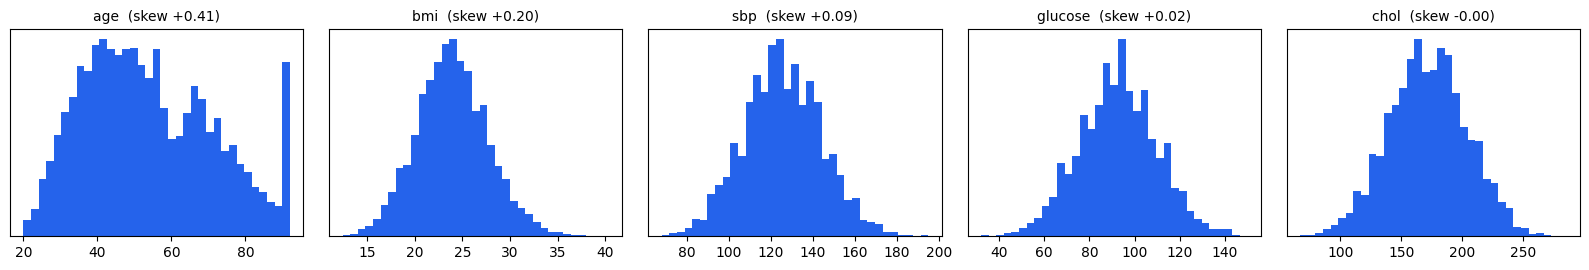

In [ ]:
CONT = ['age', 'bmi', 'sbp', 'glucose', 'chol']

fig, axes = plt.subplots(1, 5, figsize=(16, 2.8))
for ax, v in zip(axes, CONT):
    ax.hist(df[v].dropna(), bins=35, color='#2563EB')
    ax.set_title(f'{v}  (skew {stats.skew(df[v].dropna()):+.2f})', fontsize=10)
    ax.set_yticks([])
plt.tight_layout(); plt.show()

In [ ]:
# TODO ① 연속형 5개의 분포 진단표를 만드십시오.
#        왜도는 stats.skew(), 판단 기준은 |왜도| > 1

rows = []
for v in CONT:
    y = df[v].dropna()
    skewness = stats.skew(y)
    judgment = '치우침' if abs(skewness) > 1 else '대칭에 가까움'
    rows.append({'변수': v,
                 'n': len(y),
                 '최소': y.min(), '최대': y.max(),
                 '평균': round(y.mean(), 2),
                 '중앙값': round(y.median(), 2),
                 '왜도': round(skewness, 2),
                 '판단': judgment})          # |왜도|>1 이면 '치우침', 아니면 '대칭에 가까움'
pd.DataFrame(rows)

,변수,n,최소,최대,평균,중앙값,왜도,판단
0,age,5367,20.00,92.0,53.99,51.00,0.41,대칭에 가까움
1,bmi,5367,12.43,40.4,23.97,23.85,0.20,대칭에 가까움
2,sbp,5367,68.00,195.0,125.67,125.00,0.09,대칭에 가까움
3,glucose,5000,32.00,150.0,92.84,93.00,0.02,대칭에 가까움
4,chol,4806,67.00,286.0,172.05,172.00,-0.00,대칭에 가까움


## 1-2. 정규성 검정은 왜 쓸모가 없는가  ★

직접 확인해 봅시다. 왜도가 **+0.02**인 `glucose`, 거의 완벽한 대칭입니다.
여기에 Shapiro-Wilk 검정을 돌리면 어떻게 될까요?

In [ ]:
print(f"{'변수':>9} {'왜도':>8} {'Shapiro-Wilk p':>16}   판정")
for v in CONT:
    y = df[v].dropna().to_numpy()
    sub = y if len(y) <= 5000 else np.random.default_rng(0).choice(y, 5000, replace=False)
    p = stats.shapiro(sub).pvalue
    print(f'{v:>9} {stats.skew(y):>+8.2f} {p:>16.2e}   '
          f"{'정규성 기각' if p < 0.05 else '기각 못 함'}")

       변수       왜도   Shapiro-Wilk p   판정
      age    +0.41         2.29e-33   정규성 기각
      bmi    +0.20         8.33e-08   정규성 기각
      sbp    +0.09         1.59e-03   정규성 기각
  glucose    +0.02         2.97e-02   정규성 기각
     chol    -0.00         4.79e-02   정규성 기각


💬 **직접 적어보기 (2줄)**

1. 왜도가 +0.02인 `glucose`도 정규성이 기각되었는가?
2. 그렇다면 정규성 검정으로 요약통계를 결정하는 것이 왜 문제인가?

> 1. 기각되었다.
2. 정규성 검정은 표본 크기가 크면 작은 비정규성도 통계적으로 유의하다고 판단하기 쉽기 때문이다.

## 1-3. 가중 분위수 구현  ★ 오늘의 핵심 코드

평균은 가중치를 곱해서 더하면 되지만, 중앙값은 **순서**에 관한 통계량이라 방식이 다릅니다.

1. 값을 크기순으로 **정렬**
2. 가중치를 **누적**해서 전체 합으로 나눔 → 0~1 누적비율
3. 원하는 분위(0.5 등)를 넘는 지점을 **보간**

In [ ]:
import numpy as np

# TODO ② 가중 분위수 함수를 완성하십시오.
#        힌트: np.argsort, np.cumsum, np.interp
#        누적비율에 -0.5*w 보정을 넣으면 비가중일 때 np.percentile과 거의 일치합니다.

def wquantile(y, w, q):
    y = np.asarray(y, float); w = np.asarray(w, float)
    ok = ~np.isnan(y)
    y, w = y[ok], w[ok]
    o = np.argsort(y)                 # ① 정렬
    y, w = y[o], w[o]
    wc = (np.cumsum(w) - 0.5 * w) / np.sum(w)  # ② 누적 가중치 (중앙 보정 -0.5*w 포함)
    return np.interp(np.atleast_1d(q), wc, y)   # ③ 보간


# 검증: 가중치를 모두 1로 주면 np.percentile 과 거의 같아야 한다
chk = wquantile(df['age'], np.ones(len(df)), [0.25, 0.5, 0.75])
print('가중치=1 :', chk.round(1))
print('np.percentile:', np.percentile(df['age'], [25, 50, 75]).round(1))

가중치=1 : [40. 51. 67.]
np.percentile: [40. 51. 67.]


In [ ]:
# TODO ③ 연령의 비가중 / 가중 분위수를 비교하십시오.

Q = [0.25, 0.5, 0.75]
unw = np.percentile(df['age'], [q*100 for q in Q])
wtd = wquantile(df['age'], w, Q)                                   # wquantile 사용

print(f"{'':8}{'P25':>8}{'P50':>8}{'P75':>8}")
print(f"{'비가중':8}{unw[0]:>8.0f}{unw[1]:>8.0f}{unw[2]:>8.0f}")
print(f"{'가중':8}{wtd[0]:>8.0f}{wtd[1]:>8.0f}{wtd[2]:>8.0f}")
print(f"{'차이':8}{wtd[0]-unw[0]:>+8.0f}{wtd[1]-unw[1]:>+8.0f}{wtd[2]-unw[2]:>+8.0f}")

             P25     P50     P75
비가중           40      51      67
가중            37      47      59
차이            -3      -4      -8


## 1-4. 비가중 vs 가중 요약 비교

연속형 변수 전체에 대해 비교표를 만듭니다.

In [ ]:
rows = []
for v in CONT:
    y, ok = df[v], df[v].notna().to_numpy()
    th, se = svymean(y, w, ST, PS)
    rows.append({
        '변수': v,
        '비가중 평균': round(y.mean(), 2),
        '가중 평균': round(th, 2),
        '가중 SE': round(se, 3),
        '비가중 중앙값': round(y.median(), 1),
        '가중 중앙값': round(wquantile(y, w, 0.5)[0], 1),
    })
summ = pd.DataFrame(rows)
summ

,변수,비가중 평균,가중 평균,가중 SE,비가중 중앙값,가중 중앙값
0,age,53.99,49.14,0.164,51.0,47.0
1,bmi,23.97,23.81,0.054,23.9,23.7
2,sbp,125.67,122.79,0.445,125.0,123.0
3,glucose,92.84,91.59,0.249,93.0,92.0
4,chol,172.05,170.39,0.486,172.0,170.0


💬 **직접 적어보기** — 어느 변수에서 비가중과 가중의 차이가 가장 컸는가? 이유는?

> age에서 가장 컸다. 표본을 수집하는 과정에서 특정 연령대가 실제 모집단보다 더 많이 포함되어 과대표현되었기 때문이다.

## 1-5. 요약통계 결정 — 💬 직접 채우십시오

| 변수 | 왜도 | 분포 판단 | 선택한 요약통계 | 이유 |
|---|---|---|---|---|
| 변수 | 왜도 | 분포 판단 | 선택한 요약통계 | 이유 |
|---|---|---|---|---|
| **age** | 높음 (평균과 중앙값 차이 큼) | 비대칭 (우측 꼬리 분포 등) | 중앙값[IQR] | 평균과 중앙값의 차이가 크고 비대칭성이 존재하므로, 극단값의 영향을 받지 않는 중앙값과 IQR이 적절함 |
| **bmi** | 낮음 (평균과 중앙값 유사) | 대칭 (정규분포 유사) | 평균(SE) | 평균과 중앙값의 차이가 미미하고 대칭적 분포를 보이므로, 보건 통계 관행에 따라 평균(SE) 사용 |
| **sbp** | 낮음~보통 | 대략적 대칭 | 평균(SE) | 임상 연구 및 보건학 통계 관행상 활력징후는 평균과 표준오차로 제시하는 것이 표준적임 |
| **glucose** | 낮음 | 대칭 | 평균(SE) | 분포가 대칭적이어서 대표값으로 평균을 사용하는 것이 적절함 |
| **chol** | 낮음 | 대칭 | 평균(SE) | 생체 지표 데이터의 분포가 안정적이며, 전체 표의 요약통계 형식과 일관성을 유지하기 위함 |

**힌트** — 정답은 하나가 아닙니다. 왜도, 분야 관행, 표 안의 일관성 세 가지를 근거로 쓰십시오.

---
# 실습 ② — Table 1 완성

## 2-1. 설계 기반 집단 비교  ★

두 집단의 평균 차이를 구합니다. **두 추정치가 독립이 아니라는 점**이 핵심입니다.
같은 조사구 안에 남성과 여성이 함께 들어 있기 때문입니다.

$$z_i = \frac{w_i d_{1i}(y_i-\hat\mu_1)}{\sum w d_1} - \frac{w_i d_{2i}(y_i-\hat\mu_2)}{\sum w d_2}$$

In [ ]:
# TODO ④ 두 도메인 평균 차이의 설계 기반 추정을 완성하십시오.
#        각각의 분산을 그냥 더하면 안 됩니다 — 차이 자체의 잔차를 만들어야 합니다.

def svydiff(y, w, strata, psu, g1, g2):
    y = np.asarray(y, float)
    ok = ~np.isnan(y)
    yy = np.nan_to_num(y)
    d1 = np.asarray(g1, float) * ok
    d2 = np.asarray(g2, float) * ok
    W1, W2 = np.sum(w * d1), np.sum(w * d2)
    m1, m2 = np.sum(w * d1 * yy) / W1, np.sum(w * d2 * yy) / W2
    z = (w * d1 * (yy - m1)) / W1 - (w * d2 * (yy - m2)) / W2 # 차이에 대한 선형화 잔차
    return m1 - m2, np.sqrt(_var_psu(z, strata, psu))


male, female = (df.sex == 1).to_numpy(), (df.sex == 2).to_numpy()
diff, se = svydiff(df['bmi'], w, ST, PS, male, female)
print(f'BMI 남녀 차이 {diff:+.3f}  SE {se:.3f}  '
      f'95% CI [{diff-1.96*se:+.3f}, {diff+1.96*se:+.3f}]')

BMI 남녀 차이 -1.815  SE 0.106  95% CI [-2.022, -1.607]


## 2-2. SMD — 표준화 평균 차이

p값은 표본이 크면 거의 항상 유의합니다. SMD는 **표본 크기와 무관하게 차이의 크기만** 반영합니다.

- 연속형: $\text{SMD} = (m_1-m_2)/\sqrt{(s_1^2+s_2^2)/2}$
- 이분형: $\text{SMD} = (p_1-p_2)/\sqrt{(p_1q_1+p_2q_2)/2}$

In [ ]:
# TODO ⑤ 가중 표준편차와 SMD를 완성하십시오.
#        가중 SD = sqrt( Σw(y−ȳ_w)² / Σw )   ← 가중치를 '빈도'로 보면 안 됩니다

def wsd(y, w):
    y = np.asarray(y, float); w = np.asarray(w, float)
    ok = ~np.isnan(y); y, w = y[ok], w[ok]
    m = np.sum(w * y) / np.sum(w)
    return np.sqrt(np.sum(w * (y - m)**2) / np.sum(w))


def smd_cont(y, w, g1, g2):
    m1, _ = svymean_domain(y, w, ST, PS, g1)
    m2, _ = svymean_domain(y, w, ST, PS, g2)
    s1 = wsd(np.asarray(y, float)[g1], w[g1])
    s2 = wsd(np.asarray(y, float)[g2], w[g2])
    return (m1 - m2) / np.sqrt((s1**2 + s2**2) / 2)


print('BMI  SMD =', round(smd_cont(df['bmi'], w, male, female), 3))

BMI  SMD = -0.505


## 2-2b. 차이의 설계효과 — 슬라이드 15 표 재현

4주차에서 **평균·비율**의 Deff를 구했습니다 (비만 1.17 · 고혈압 1.50 · 수축기혈압 3.11).
이번에는 **집단 간 차이**의 Deff를 구해 같은 단위로 비교합니다.

두 숫자를 구별하십시오 — **SE 비**는 설계 SE ÷ 단순 SE이고, **Deff는 그것을 제곱한 값**입니다.
비교는 반드시 Deff끼리 합니다.

두 비율차의 단순 SE는 √(p₁q₁/n₁ + p₂q₂/n₂) 입니다 (p·n은 비가중).

In [ ]:
def srs_se_diff(y, g1, g2):
    """두 비율차의 단순무작위 가정 표준오차 (비가중 p, 비가중 n)"""
    y = np.asarray(y, float)
    n1, n2 = int(np.sum(g1)), int(np.sum(g2))
    p1, p2 = y[g1].mean(), y[g2].mean()
    return np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)


obes_i = (df['bmi'] >= 25).astype(float).to_numpy()
htn_i  = df['htn'].astype(float).to_numpy()
hdrk_i = (df['drink'] == 3).astype(float).to_numpy()
ex_yes, ex_no = (df.exercise == 2).to_numpy(), (df.exercise == 1).to_numpy()
dong, eup = (df.urban == 1).to_numpy(), (df.urban == 2).to_numpy()

CASES = [('성별 × 비만',       obes_i, male,   female),
         ('운동 × 고혈압',      htn_i,  ex_no,  ex_yes),
         ('성별 × 고위험음주',  hdrk_i, male,   female),
         ('동읍면 × 고혈압',    htn_i,  dong,   eup)]

rows = []
for lab, y, g1, g2 in CASES:
    d, se_d = svydiff(y, w, ST, PS, g1, g2)
    se_s = srs_se_diff(y, g1, g2)
    rows.append([lab, round(d*100, 2), round(se_d*100, 4), round(se_s*100, 4),
                 round(se_d/se_s, 2), round((se_d/se_s)**2, 2)])
print(pd.DataFrame(rows, columns=['비교', '가중 비율차(%p)', '설계 SE(%p)',
                                  '단순 SE(%p)', 'SE 비', 'Deff']).to_string(index=False))
print()
print('차이의 Deff 0.94~1.63  vs  평균·비율의 Deff 1.17~3.11 (4주차)')
print('동읍면만 큰 이유: 조사구가 동부 아니면 읍면부에 통째로 속해 상쇄가 일어나지 않는다.')

        비교  가중 비율차(%p)  설계 SE(%p)  단순 SE(%p)  SE 비  Deff
   성별 × 비만      -20.53     1.4177     1.2958  1.09  1.20
  운동 × 고혈압        1.45     1.2339     1.2737  0.97  0.94
성별 × 고위험음주       -0.62     1.3356     1.1753  1.14  1.29
 동읍면 × 고혈압      -10.31     1.6576     1.3003  1.27  1.63

차이의 Deff 0.94~1.63  vs  평균·비율의 Deff 1.17~3.11 (4주차)
동읍면만 큰 이유: 조사구가 동부 아니면 읍면부에 통째로 속해 상쇄가 일어나지 않는다.


## 2-3. p값 vs SMD — 정면 비교  ★

In [ ]:
rows = []
for v in CONT:
    diff, se = svydiff(df[v], w, ST, PS, male, female)
    z = diff / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    smd = smd_cont(df[v], w, male, female)
    rows.append({'변수': v,
                 '가중 남녀 차이': round(diff, 2),
                 '설계 SE': round(se, 3),
                 '설계 기반 p': f'{p:.3f}' if p >= 0.001 else '< 0.001',
                 'SMD': round(smd, 3),
                 '판정': ('무시할 만함' if abs(smd) < 0.1 else
                         '작은 차이' if abs(smd) < 0.3 else '뚜렷한 차이')})
cmp_tbl = pd.DataFrame(rows)
cmp_tbl

,변수,가중 남녀 차이,설계 SE,설계 기반 p,SMD,판정
0,age,-0.02,0.426,0.967,-0.001,무시할 만함
1,bmi,-1.81,0.106,< 0.001,-0.505,뚜렷한 차이
2,sbp,-1.88,0.515,< 0.001,-0.105,작은 차이
3,glucose,-1.39,0.499,0.005,-0.081,무시할 만함
4,chol,-2.92,0.975,0.003,-0.091,무시할 만함


💬 **직접 해석하기 (3줄)**

1. 설계 기반 p가 0.01보다 작은데 SMD는 0.1 미만인 변수는 무엇인가?
2. 그 변수의 실제 차이(단위 포함)는 얼마인가? 임상적으로 의미가 있는가?
3. 왜 p값을 Table 1에 적지 말라고 하는지 자기 말로 설명하시오.

>1.glucose, chol

2.glucose: -1.39 mg/dL
chol: -2.92 mg/dL

  통계적으로는 유의하지만 실제 차이의 크기가 매우 작아 임상적으로 의미가 없다.

  3.통계적 유의성이 실제 차이의 크기나 중요도를 반영하지 못하기 때문이다.

## 2-4. Table 1 조립  ★

**규칙** — n은 관측 수, %와 평균은 가중치 적용. 층화 열은 **도메인 분석**으로 만듭니다.

In [ ]:
# TODO ⑥ Table 1의 행 생성 함수를 완성하십시오.
#        핵심: 층화 열도 자료를 자르지 말고 도메인 분석으로 만든다

DOMS = {'전체': np.ones(len(df), bool), '남성': male, '여성': female}

def row_cont(label, var):
    """연속형: 가중 평균 (SE)"""
    r = {'특성': label, 'n': int(df[var].notna().sum())}
    for name, dom in DOMS.items():
        th, se = svymean_domain(df[var], w, ST, PS, dom)                      # svymean_domain 사용
        r[name] = f'{th:.1f} ({se:.2f})'
    return r

def row_cat(label, mask):
    """범주형: n (가중 %)"""
    mask = np.asarray(mask, float)
    r = {'특성': label, 'n': int(mask.sum())}
    for name, dom in DOMS.items():
        th, se = svymean_domain(mask, w, ST, PS, dom)                      # 지시변수의 도메인 가중평균
        r[name] = f'{th*100:.1f}'
    return r

t1 = pd.DataFrame([
    row_cont('연령 (세)', 'age'),
    row_cat('  65세 이상', df.age >= 65),
    row_cat('남성', df.sex == 1),
    row_cat('읍면 거주', df.urban == 2),
    row_cont('BMI (kg/m²)', 'bmi'),
    row_cat('  비만 (BMI≥25)', df.bmi >= 25),
    row_cont('수축기혈압 (mmHg)', 'sbp'),
    row_cat('고혈압', df.htn == 1),
    row_cat('현재흡연', df.smk == 1),
    row_cat('규칙적 운동', df.exercise == 2),
])
t1

,특성,n,전체,남성,여성
0,연령 (세),5367,49.1 (0.16),49.1 (0.27),49.1 (0.27)
1,65세 이상,1607,16.8,16.6,17.0
2,남성,2719,49.0,100.0,0.0
3,읍면 거주,2156,22.9,23.0,22.9
4,BMI (kg/m²),5367,23.8 (0.05),22.9 (0.07),24.7 (0.08)
5,비만 (BMI≥25),2035,36.5,26.0,46.6
6,수축기혈압 (mmHg),5367,122.8 (0.45),121.8 (0.50),123.7 (0.52)
7,고혈압,1652,24.4,23.6,25.1
8,현재흡연,1295,24.1,35.2,13.5
9,규칙적 운동,2238,41.5,40.9,42.1


## 2-5. 각주 작성 — 네 항목

각주는 선택이 아니라 표의 일부입니다.

💬 **직접 작성하십시오** — 아래 네 항목이 모두 들어가야 합니다.

1. n은 관측 수, %와 평균은 가중 추정치라는 것
2. 연속형 변수를 어떤 통계량으로 요약했는지
3. 집단 비교에 사용한 방법 (SMD 기준 포함)
4. 결측이 있었다면 그 처리 방식

> **각주:** 값은 관측 수(n), 가중 백분율(%) 또는 가중 평균(표준오차,SE)로 제시되었고 연속형 변수는 가중평균(SE)로 요약됨

집단 간 비교는 조사 설계 가중치를 반영한 방법을 사용하였고, 차이의 크기는 표준화 평균 차이(SMD)로 평가하였으며 절댓값이 0.1미만인 경우는 무시할 만한 수준으로 간주함

그리고 결측치가 있는 관측치는 각 변수별 분석에서 제외됨

## 2-6. 결측 확인

Table 1은 **관측된 자료**를 기술하는 표입니다. 결측이 있는 변수는 n을 함께 표시합니다.

In [ ]:
miss = (df[CONT + ['income', 'edu']].isna().mean() * 100).round(1)
print('변수별 결측률 (%)')
print(miss[miss > 0].to_string())
print(f"\n  income == 9 (코드 결측): {(df.income == 9).sum()}명 "
      f"({(df.income == 9).mean()*100:.1f}%)")
print('  → 3주차 규칙: 코드 결측을 NaN으로 바꾼 뒤 Table 1을 만들어야 한다')

변수별 결측률 (%)
glucose     6.8
chol       10.5

  income == 9 (코드 결측): 326명 (6.1%)
  → 3주차 규칙: 코드 결측을 NaN으로 바꾼 뒤 Table 1을 만들어야 한다


## 2-7. 결과 저장

In [ ]:
t1.to_csv('week5_table1.csv', index=False, encoding='utf-8-sig')
cmp_tbl.to_csv('week5_pvalue_vs_smd.csv', index=False, encoding='utf-8-sig')
summ.to_csv('week5_weighted_summary.csv', index=False, encoding='utf-8-sig')

print('저장 완료:')
for f in ['week5_table1.csv', 'week5_pvalue_vs_smd.csv', 'week5_weighted_summary.csv']:
    print('  -', f)
print('\n※ week5_table1.csv 는 6주차 회귀분석에서 그대로 사용합니다.')

저장 완료:
  - week5_table1.csv
  - week5_pvalue_vs_smd.csv
  - week5_weighted_summary.csv

※ week5_table1.csv 는 6주차 회귀분석에서 그대로 사용합니다.


### Methods 예시 문장 (여러분의 숫자로 바꿔 쓰십시오)

> "연속형 변수는 분포를 확인한 뒤 가중 평균과 표준오차로, 범주형 변수는 관측 빈도와
> 가중 백분율로 제시하였다. 집단 간 차이는 층(**18**개)과 조사구(**263**개)를 반영한
> 설계 기반 검정으로 평가하고 표준화 평균 차이를 함께 제시하였다.
> 성별 층화 결과는 도메인 분석으로 산출하였다."

---
# 제출 체크리스트

**실습 ①**
- [ ] 연속형 5개의 히스토그램·왜도 확인
- [ ] Shapiro-Wilk 결과와 해석 2줄
- [ ] 가중 분위수 함수 구현 + 검증(가중치=1)
- [ ] 비가중 / 가중 요약 비교표
- [ ] 변수별 요약통계 결정과 근거

**실습 ②**
- [ ] 설계 기반 집단 비교 함수
- [ ] p값 vs SMD 비교표 + 해석 3줄
- [ ] Table 1 완성 (전체 · 남성 · 여성)
- [ ] 각주 4항목
- [ ] 💬 칸을 모두 채웠는가

**과제 제출 — 파일로 냅니다 (개인별)**
- [ ] **런타임 → 모두 실행**으로 처음부터 끝까지 다시 실행
- [ ] **파일 → 다운로드 → .ipynb 다운로드**
- [ ] 파일명을 `5주차_학번_이름.ipynb` 로 변경
- [ ] 내려받은 파일을 열어 표와 그림이 보이는지 확인
- [ ] LMS 과제란에 업로드 (GitHub 링크가 아니라 파일)